# <b>Loan Default Risk Prediction</b>

## <b>Exploratory Data Analysis (EDA)</b>

### <b>Session 1: Dataset Overview</b>

**Objective:**

The objective of this session is to understand the overall structure of the dataset before performing any preprocessing or feature engineering.

In this session, we will:

- Load the dataset using the Data Ingestion Pipeline
- Inspect the dataset structure
- Understand the dimensions of the dataset
- Identify numerical and categorical features
- Check missing values and duplicate records

#### <b>Step 1: Import Required Libraries</b>

We begin by importing the required libraries for data manipulation and loading the dataset.

Notice that we are **not using `pd.read_csv()` directly**. Instead, we load the data through our production Data Ingestion component.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.components.data_ingestion import DataIngestion

#### <b>Step 2: Load Dataset</b>

The dataset is loaded using the Data Ingestion pipeline.

Using a centralized ingestion component improves maintainability because any future change in the data source only needs to be updated in one place.

In [2]:
ingestion  = DataIngestion()
df = ingestion.load_data()

[2026-07-23 12:43:43,441] INFO - loan_default_project - Loading dataset from: D:\MachineLearningProjects\Loan_Default_Risk_Prediction\data\raw\application_train.csv
[2026-07-23 12:43:58,888] INFO - loan_default_project - Dataset loaded successfully with shape: (307511, 122)


#### <b>Step 3: Display First Five Records</b>

The `head()` function displays the first five rows of the dataset.

This helps us verify:

- Column names
- Data types
- Sample values
- Overall dataset structure

Instead of printing the complete dataset, which contains more than 300,000 records, we inspect only a small sample.

In [3]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


##### <b>Observation</b>

- The dataset contains customer demographic and financial information.
- Each row represents one loan application.
- The target variable is **TARGET**.
- The dataset contains both numerical and categorical variables.

#### <b>Step 4: Check Dataset Shape</b>

The shape of the dataset tells us the number of rows and columns available for analysis.

In [4]:
df.shape

(307511, 122)

##### <b>Observation</b>

The dataset contains:

- **307,511 rows**
- **122 columns**

This indicates a relatively large dataset with many features that will require preprocessing before model training.

#### <b>Step 5: Dataset Information</b>

The `info()` function provides:

- Number of rows
- Number of columns
- Non-null values
- Data types
- Memory usage

This is one of the first commands every Data Scientist runs before starting EDA.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


##### <b>Observation</b>

From the dataset information we observe:

- Multiple columns contain missing values.
- Both numerical and categorical features are present.
- Most numerical columns are stored as `float64` or `int64`.
- Several categorical columns are stored as `object`.

#### <b>Step 6: Statistical Summary</b>

The `describe()` function summarizes the numerical features.

It provides:

- Count
- Mean
- Standard Deviation
- Minimum
- Quartiles
- Maximum

In [6]:
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


##### <b>Observation</b>

The statistical summary helps us identify:

- Features with large ranges
- Possible outliers
- Skewed distributions
- Missing values (through reduced count)

#### <b>Step 7: Missing Value Analysis</b>

Before cleaning the data, we identify which columns contain missing values.

This helps us decide the appropriate imputation strategy during preprocessing.

In [7]:
df.isnull().sum().sort_values(ascending=False).head(10)

COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
COMMONAREA_MEDI             214865
NONLIVINGAPARTMENTS_MEDI    213514
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_AVG     213514
FONDKAPREMONT_MODE          210295
LIVINGAPARTMENTS_AVG        210199
LIVINGAPARTMENTS_MEDI       210199
LIVINGAPARTMENTS_MODE       210199
dtype: int64

##### <b>Observation</b>

Several columns contain a high percentage of missing values.

These columns will require careful handling during the feature engineering stage.

At this point, we only identify missing values—we do not remove or impute them.

#### <b>Session 1 Summary</b>

In this session we:

- Successfully loaded the dataset
- Understood the dataset dimensions
- Explored the dataset structure
- Identified numerical and categorical features
- Checked duplicate records
- Identified missing values
- Generated initial business observations

The dataset is now ready for deeper exploratory analysis in the next session.

### <b>Session 2: Target Variable Analysis</b>

**Objective**

The objective of this session is to understand the distribution of the target variable and determine whether the dataset is balanced or imbalanced.

The target variable is `TARGET`, where:

- `0` represents a customer who repaid the loan or did not experience payment difficulty.
- `1` represents a customer who defaulted or experienced payment difficulty.

Target analysis is important because class distribution directly affects model training, evaluation metrics, and sampling strategies.

#### <b>Business Context</b>

The organization wants to identify customers who are likely to default before approving a loan.

In this business problem:

- Correctly identifying a defaulter helps reduce financial loss.
- Missing an actual defaulter can be costly.
- Incorrectly classifying a reliable customer as risky may result in additional verification or rejection of a potentially profitable customer.

Therefore, understanding the number of defaulters and non-defaulters is essential before building the classification model.

#### <b>Step 1: Verify the Target Column</b>

Before analyzing the target variable, we first confirm that the `TARGET` column is present in the dataset.

This prevents the analysis from continuing with an incomplete or incorrect dataset.

In [8]:
target_column = "TARGET"
if target_column not in df.columns:
    raise ValueError(f"Target Column `{target_column}` is missing from the dataset.")
print(f"Target Column '{target_column}' is present.")

Target Column 'TARGET' is present.


#### <b>Step 2: Check Unique Values in the Target Column</b>

A binary classification target should contain two valid classes.

For this project, the expected values are:

- `0`: No default
- `1`: Default

Checking unique values also helps identify unexpected labels or data-quality problems.

In [9]:
target_values = sorted(df[target_column].dropna().unique().tolist())
print(f"Unique target values: {target_values}")

Unique target values: [0, 1]


##### <b>Observation</b>

The `TARGET` column contains two unique values: `0` and `1`.

Therefore, this is a binary classification problem.

No unexpected target labels were identified.

#### <b>Step 3: Check Missing Values in the Target Column</b>

The target column must contain valid labels for model training.

Rows with a missing target cannot be directly used in supervised learning because the expected outcome is unknown.

In [10]:
target_missing_count = df[target_column].isnull().sum()
target_missing_percentage = (
    target_missing_count / len(df)
) * 100

print("Missing target values:", target_missing_count)
print(f"Missing target percentage: {target_missing_percentage:.2f}%")

Missing target values: 0
Missing target percentage: 0.00%


##### <b>Observation</b>

The `TARGET` column does not contain any missing values.

This means every record has a known loan repayment outcome and can potentially be used for supervised model training.

#### <b>Step 4: Calculate the Number of Records in Each Target Class</b>

The `value_counts()` function calculates how many customers belong to each target category.

This helps us compare the number of non-default and default cases.

In [11]:
target_counts = df[target_column].value_counts().sort_index()
print(target_counts)

TARGET
0    282686
1     24825
Name: count, dtype: int64


##### <b>Observation</b>

The dataset contains approximately:

- **282,686 non-default customers**
- **24,825 default customers**

The number of customers who did not default is substantially higher than the number of customers who defaulted.

#### <b>Step 5: Calculate the Percentage Distribution of the Target</b>

Counts show the absolute number of records, while percentages make it easier to understand the relative distribution of each class.

In [12]:
target_percentage = df[target_column].value_counts(normalize=True).sort_index().mul(100).round(2)

print(target_percentage)

TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64


##### <b>Observation</b>

Approximately:

- **91.93%** of customers belong to the non-default class.
- **8.07%** of customers belong to the default class.

The target classes are not equally distributed. The default class is significantly smaller than the non-default class.

#### <b>Step 6: Create a Target Distribution Summary</b>

A summary table combines target labels, customer counts, and class percentages in a clear and readable format.

In [13]:
target_summary = pd.DataFrame({
    "Target": target_counts.index,
    "Customer_Count": target_counts.values,
    "Percentage": target_percentage.values
})

target_summary['Class_Label'] = target_summary['Target'].map(
    {
        0: "No Default",
        1: "Default"
    }
)

target_summary = target_summary[
    [
        "Target",
        "Class_Label",
        "Customer_Count",
        "Percentage"
    ]
]

print(target_summary)

   Target Class_Label  Customer_Count  Percentage
0       0  No Default          282686       91.93
1       1     Default           24825        8.07


#### <b>Step 7: Visualize the Target Distribution</b>

A bar chart allows us to visually compare the size of the two target classes.

A large difference between the bars indicates class imbalance.

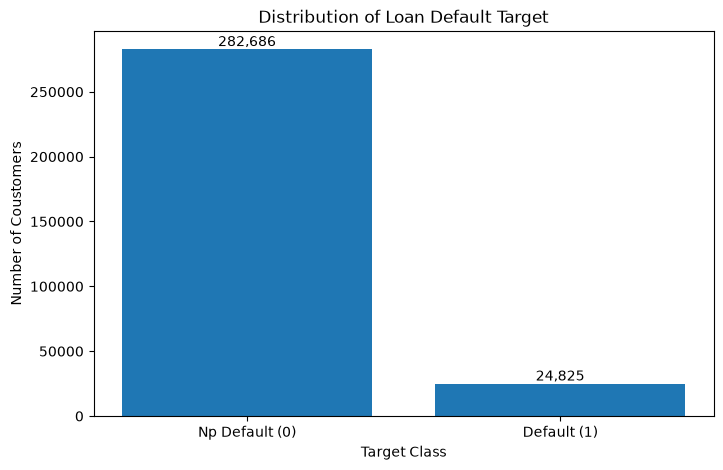

In [14]:
class_labels = ["Np Default (0)", "Default (1)"]
fig,ax = plt.subplots(figsize=(8,5))
bars = ax.bar(class_labels, target_counts.values)
ax.set_title("Distribution of Loan Default Target")
ax.set_xlabel("Target Class")
ax.set_ylabel("Number of Coustomers")

for bar, count in zip(bars, target_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}",
        ha="center",
        va="bottom"
    )

plt.show()

##### <b>Observation</b>

The non-default class is much larger than the default class.

This confirms that the dataset is imbalanced.

A model trained without considering this imbalance may become biased toward predicting the majority class.

#### <b>Step 8: Visualize the Percentage of Each Target Class</b>

The following chart shows the percentage contribution of each class.

This representation makes the degree of class imbalance easier to interpret.

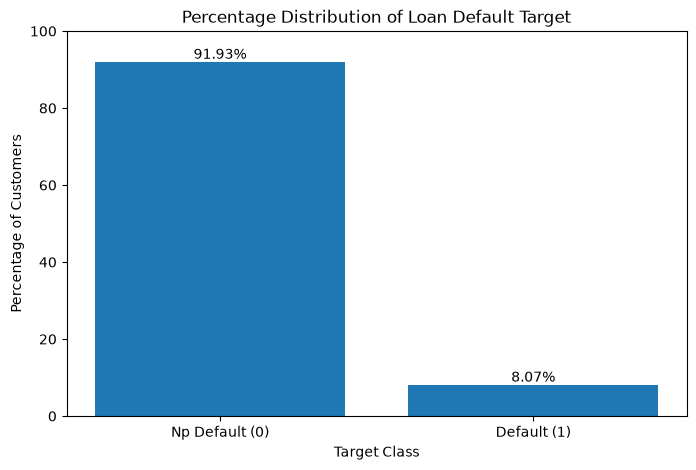

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    class_labels,
    target_percentage.values,
)

ax.set_title("Percentage Distribution of Loan Default Target")
ax.set_xlabel("Target Class")
ax.set_ylabel("Percentage of Customers")
ax.set_ylim(0, 100)

for bar, percentage in zip(bars, target_percentage.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{percentage:.2f}%",
        ha="center",
        va="bottom",
    )

plt.show()

#### <b>Step 9: Calculate the Class-Imbalance Ratio</b>

The imbalance ratio compares the number of majority-class records with the number of minority-class records.

It helps quantify how much larger the non-default class is than the default class.

In [16]:
non_default_count = target_counts.get(0,0)
default_count = target_counts.get(1,0)

if default_count==0:
    raise ValueError(
        "The default class contains no records. "
        "The imbalance ratio can't be calculated."
    )
imbalance_ratio = non_default_count/default_count
print("Class imbalance ratio: ", f"{imbalance_ratio:.2f}:1")

Class imbalance ratio:  11.39:1


##### <b>Observation</b>

For approximately every one customer who defaults, there are more than eleven customers who do not default.

This is a significant class imbalance and must be considered during:

- Train-test splitting
- Model training
- Model evaluation
- Threshold selection
- Sampling or class-weight decisions

#### <b>Step 10: Why Accuracy Can Be Misleading</b>

Suppose a model predicts every customer as `0`, meaning no customer will default.

Because approximately 91.93% of the records belong to class `0`, this model would achieve approximately 91.93% accuracy.

However, it would fail to identify every actual defaulter.

Therefore, high accuracy does not necessarily mean that the model is useful for the business.

In [17]:
majority_class_accuracy = (
    non_default_count / len(df)
) * 100

print(
    "Accuracy obtained by predicting every customer as non-default:",
    f"{majority_class_accuracy:.2f}%",
)

Accuracy obtained by predicting every customer as non-default: 91.93%


##### <b>Business Interpretation</b>

A model that always predicts `No Default` would achieve high accuracy but would detect none of the actual defaulters.

Such a model would expose the company to financial losses because risky customers could still receive loans.

Therefore, accuracy alone should not be used as the primary model evaluation metric for this project.

#### <b>Step 11: Select Appropriate Evaluation Metrics</b>

Because the dataset is imbalanced, the model should be evaluated using metrics that measure performance on the minority class.

The following metrics will be important:

##### <b>Recall</b>

Recall measures how many actual defaulters are correctly detected.

A high recall means the model misses fewer risky customers.

##### <b>Precision</b>

Precision measures how many customers predicted as defaulters actually defaulted.

A high precision reduces unnecessary rejection or investigation of reliable customers.

##### <b>F1-Score</b>

F1-score balances precision and recall.

It is useful when both false positives and false negatives are important.

##### <b>ROC-AUC</b>

ROC-AUC measures the model's ability to rank default customers above non-default customers across different classification thresholds.

##### <b>PR-AUC</b>

Precision-Recall AUC is especially useful for imbalanced datasets because it focuses more directly on performance for the positive minority class.

##### <b>Metric Priority for This Project</b>

Recall will be an important metric because failing to detect an actual defaulter can cause financial loss.

However, maximizing recall without considering precision may result in too many reliable customers being classified as risky.

Therefore, the final model should balance:

- Recall
- Precision
- F1-score
- ROC-AUC
- Precision-Recall AUC

The final decision threshold should also be selected according to the business cost of false positives and false negatives.

#### <b>Step 12: Business Meaning of Classification Errors</b>

##### <b>False Positive</b>

The model predicts that a customer will default, but the customer would actually repay the loan.

Possible business consequence:

- A reliable customer may face additional verification.
- The loan may be rejected.
- The company may lose a profitable customer.

##### <b>False Negative</b>

The model predicts that a customer will repay the loan, but the customer actually defaults.

Possible business consequence:

- The company may approve a high-risk loan.
- The lender may experience financial loss.
- Recovery and collection costs may increase.

In loan default prediction, false negatives are generally considered especially costly because actual defaulters are missed.

#### <b>Step 13: Modeling Decisions Based on Target Distribution</b>

The target analysis suggests the following modeling decisions:

1. Use a stratified train-test split to preserve the target distribution.
2. Avoid evaluating the model using accuracy alone.
3. Compare recall, precision, F1-score, ROC-AUC, and PR-AUC.
4. Consider class-weighted algorithms.
5. Experiment with sampling techniques only on the training data.
6. Evaluate probability thresholds according to business cost.
7. Compare the model against a majority-class baseline.

##### <b>Important Note About Resampling</b>

Techniques such as SMOTE may be tested later, but they must only be applied to the training dataset.

Applying SMOTE before train-test splitting would create data leakage because synthetic information derived from the complete dataset could influence the test set.

We will compare multiple strategies instead of assuming that SMOTE is automatically the best solution:

- No resampling
- Class weights
- Random undersampling
- Random oversampling
- SMOTE
- Threshold tuning

#### <b>Business Insights</b>

1. Loan defaults represent only a small portion of all applications.
2. Most customers repay their loans, while approximately 8% experience payment difficulty.
3. A model that predicts every customer as non-default can still achieve more than 91% accuracy.
4. Accuracy alone would therefore provide a misleading view of model performance.
5. Missing an actual defaulter may cause direct financial loss.
6. Incorrectly identifying a reliable customer as risky may reduce business opportunities.
7. The final modeling strategy must balance risk reduction with customer approval opportunities.

#### <b>Session 2 Summary</b>

In this session, we:

- Verified the target column
- Confirmed that the problem is binary classification
- Checked missing values in the target
- Calculated target counts and percentages
- Visualized the target distribution
- Measured the class-imbalance ratio
- Demonstrated why accuracy can be misleading
- Identified suitable evaluation metrics
- Interpreted false positives and false negatives
- Defined initial modeling decisions

The dataset is imbalanced, with the default class representing approximately 8% of the observations.

The next session will focus on missing-value analysis across all input features.

### <b>Session 3: Missing-Value Analysis</b>

**Objective**

The objective of this session is to identify, measure, and interpret missing values in the loan application dataset.

Missing-value analysis is important because incomplete information can:

- Reduce the quality of model training
- Cause some machine-learning algorithms to fail
- Introduce bias when handled incorrectly
- Reveal useful business patterns
- Influence feature-selection and imputation decisions

In this session, we will analyze missing values without modifying the original dataset.

#### <b>Business Context</b>

Loan applications may contain missing values for several reasons.

For example:

- A customer may not own a house, car, or property.
- A particular document may not have been submitted.
- External credit-score information may not be available.
- Some fields may not apply to every customer.
- Data may have been lost or incorrectly recorded.

Therefore, a missing value does not always mean that the data is incorrect.

Before deciding how to handle missing values, we must understand their frequency, meaning, and relationship with the business problem.

#### <b>Step 1: Calculate the Total Number of Missing Values</b>

We begin by calculating the total number of missing values across the complete dataset.

This provides a high-level understanding of the overall data-completeness problem.

In [18]:
total_missing_values = int(df.isnull().sum().sum())
print(f"Total Missing values: {total_missing_values:,}")

Total Missing values: 9,152,465


##### <b>Observation</b>

The dataset contains a substantial number of missing values across multiple features.

However, the total count alone is not sufficient because:

- The dataset contains more than 300,000 rows.
- Some columns may contain very few missing values.
- Other columns may contain missing values for most customers.

Therefore, we need to analyze missing values column by column.

#### <b>Step 2: Count Features Containing Missing Values</b>

We calculate how many columns contain at least one missing value.

This helps us understand whether missingness is limited to a few features or spread across a large portion of the dataset.

In [19]:
missing_count_by_column = df.isnull().sum()
columns_with_missing = int((missing_count_by_column>0).sum())
columns_without_missing = int((missing_count_by_column==0).sum())
print(f"Total columns: {df.shape[1]}")
print(f"Columns with missing values: {columns_with_missing}")
print(f"Columns without missing values: {columns_without_missing}")

Total columns: 122
Columns with missing values: 67
Columns without missing values: 55


##### <b>Observation</b>

A large number of features contain at least one missing value.

This indicates that missing-value handling will be an important part of the preprocessing pipeline.

Different features may require different strategies instead of applying one common rule to every column.

#### <b>Step 3: Create a Missing-Value Summary Table</b>

For every feature, we calculate:

- Number of missing values
- Percentage of missing values
- Data type

The percentage is more informative than the raw count because it allows features to be compared consistently.

In [20]:
missing_summary = pd.DataFrame(
    {
        'Column': df.columns,
        'Missing_Count': df.isnull().sum().values,
        'Missing_Percentage' : (df.isnull().mean().values *100),
        'Data_Type': df.dtypes.astype(str).values
    }
)
missing_summary = missing_summary[missing_summary["Missing_Count"]>0].sort_values(by="Missing_Percentage", ascending=False).reset_index(drop=True)

missing_summary['Missing_Percentage'] = missing_summary['Missing_Percentage'].round(2)

missing_summary.head(20)

,Column,Missing_Count,Missing_Percentage,Data_Type
0,COMMONAREA_MEDI,214865,69.87,float64
1,COMMONAREA_MODE,214865,69.87,float64
2,COMMONAREA_AVG,214865,69.87,float64
3,NONLIVINGAPARTMENTS_MODE,213514,69.43,float64
4,NONLIVINGAPARTMENTS_MEDI,213514,69.43,float64
5,NONLIVINGAPARTMENTS_AVG,213514,69.43,float64
6,FONDKAPREMONT_MODE,210295,68.39,object
7,LIVINGAPARTMENTS_AVG,210199,68.35,float64
8,LIVINGAPARTMENTS_MEDI,210199,68.35,float64
9,LIVINGAPARTMENTS_MODE,210199,68.35,float64


##### <b>Observation</b>

The summary table shows that some features contain a very high percentage of missing values.

Features with high missing percentages may provide limited information, but they should not be removed automatically.

Before dropping any feature, we should consider:

- Its business meaning
- Its predictive importance
- Whether missingness itself carries information
- Whether the feature can be reliably imputed

#### <b>Step 4: Identify Features with the Highest Missing Percentages</b>

The following table displays the 20 features with the highest missing-value percentages.

These features will require special attention during preprocessing and feature selection.

In [21]:
top_missing_features = missing_summary.head(20)
print(top_missing_features)

                      Column  Missing_Count  Missing_Percentage Data_Type
0            COMMONAREA_MEDI         214865               69.87   float64
1            COMMONAREA_MODE         214865               69.87   float64
2             COMMONAREA_AVG         214865               69.87   float64
3   NONLIVINGAPARTMENTS_MODE         213514               69.43   float64
4   NONLIVINGAPARTMENTS_MEDI         213514               69.43   float64
5    NONLIVINGAPARTMENTS_AVG         213514               69.43   float64
6         FONDKAPREMONT_MODE         210295               68.39    object
7       LIVINGAPARTMENTS_AVG         210199               68.35   float64
8      LIVINGAPARTMENTS_MEDI         210199               68.35   float64
9      LIVINGAPARTMENTS_MODE         210199               68.35   float64
10            FLOORSMIN_MEDI         208642               67.85   float64
11            FLOORSMIN_MODE         208642               67.85   float64
12             FLOORSMIN_AVG         2

#### <b>Step 5: Visualize the Features with the Highest Missing Percentages</b>

A horizontal bar chart makes it easier to compare features with large amounts of missing data.

Only the top 20 features are displayed to keep the chart readable.

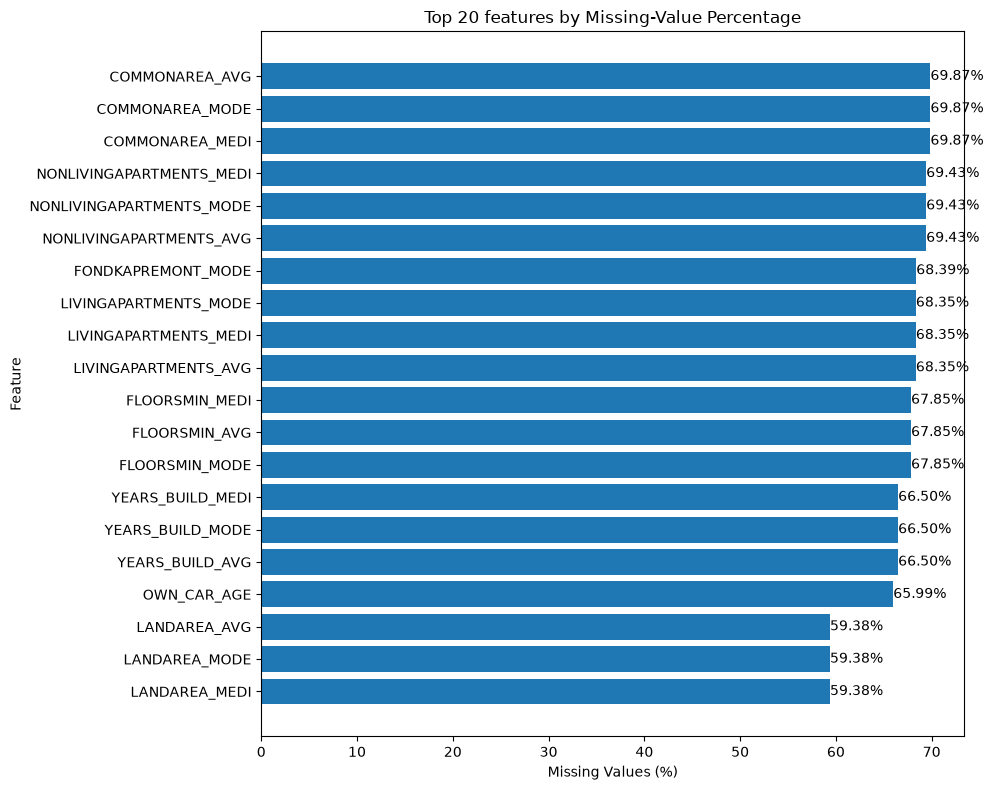

In [22]:
top_missing_for_plot = missing_summary.head(20).sort_values(by="Missing_Percentage", ascending=True)

fig,ax = plt.subplots(figsize=(10,8))
bars = ax.barh(top_missing_for_plot['Column'],
               top_missing_for_plot['Missing_Percentage'])
ax.set_title("Top 20 features by Missing-Value Percentage")
ax.set_xlabel("Missing Values (%)")
ax.set_ylabel("Feature")

for bar, percentage in zip(bars, top_missing_for_plot['Missing_Percentage']):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f"{percentage:.2f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

##### <b>Observation</b>

Several property-related features contain very high missing-value percentages.

One possible explanation is that these features may apply only to customers who own or occupy certain types of property.

The missing values may therefore represent:

- Information not provided
- Information unavailable
- A feature not applicable to the customer

This should be confirmed using the column descriptions and business knowledge before making preprocessing decisions.

#### <b>Step 6: Categorize Features by Missing-Value Severity</b>

To make the analysis easier, we group features into missing-value ranges.

The ranges used are:

- No missing values
- More than 0% and up to 10%
- More than 10% and up to 30%
- More than 30% and up to 50%
- More than 50%

In [23]:
missing_percentage_all = (
    df.isnull().mean() * 100
)

missing_severity = {
    "No Missing Values": int(
        (missing_percentage_all == 0).sum()
    ),
    "0% to 10%": int(
        (
            (missing_percentage_all > 0)
            & (missing_percentage_all <= 10)
        ).sum()
    ),
    "10% to 30%": int(
        (
            (missing_percentage_all > 10)
            & (missing_percentage_all <= 30)
        ).sum()
    ),
    "30% to 50%": int(
        (
            (missing_percentage_all > 30)
            & (missing_percentage_all <= 50)
        ).sum()
    ),
    "Above 50%": int(
        (missing_percentage_all > 50).sum()
    ),
}

missing_severity_df = pd.DataFrame(
    {
        "Missing_Range": missing_severity.keys(),
        "Feature_Count": missing_severity.values(),
    }
)

print(missing_severity_df)

       Missing_Range  Feature_Count
0  No Missing Values             55
1          0% to 10%             10
2         10% to 30%              7
3         30% to 50%              9
4          Above 50%             41


##### <b>Business Interpretation</b>

The missing-value severity groups help us prioritize preprocessing work.

For example:

- Features with low missingness may be imputed using simple methods.
- Features with moderate missingness require more careful analysis.
- Features with very high missingness may be dropped, retained with missing indicators, or imputed using domain-specific rules.

No decision should be made only on the basis of a percentage threshold.

#### <b>Step 7: Check for Completely Empty Features</b>

A completely empty feature contains missing values for every record.

Such a feature provides no usable information and would normally be removed from the modeling dataset.

In [24]:
completely_empty_columns = (
    missing_percentage_all[
        missing_percentage_all == 100
    ]
    .index
    .tolist()
)

print(
    "Number of completely empty columns:",
    len(completely_empty_columns),
)

print(
    "Completely empty columns:",
    completely_empty_columns,
)

Number of completely empty columns: 0
Completely empty columns: []


##### <b>Observation</b>

If no columns are returned, the dataset does not contain any completely empty features.

This means every feature contains at least some available information.

However, features with very high missingness may still require additional review.

#### <b>Step 8: Analyze Missing Values by Feature Type</b>

Numerical and categorical features usually require different missing-value treatments.

Typical strategies include:

##### Numerical Features

- Median imputation
- Mean imputation
- Constant-value imputation
- Model-based imputation

##### Categorical Features

- Most-frequent category
- A separate `Unknown` category
- Business-specific category mapping

We first calculate how many numerical and categorical features contain missing values.

In [25]:
numerical_columns = df.select_dtypes(
    include="number"
).columns

categorical_columns = df.select_dtypes(
    include="object"
).columns

numerical_missing_columns = [
    column
    for column in numerical_columns
    if df[column].isnull().any()
]

categorical_missing_columns = [
    column
    for column in categorical_columns
    if df[column].isnull().any()
]

print(
    "Numerical columns with missing values:",
    len(numerical_missing_columns),
)

print(
    "Categorical columns with missing values:",
    len(categorical_missing_columns),
)

Numerical columns with missing values: 61
Categorical columns with missing values: 6


##### <b>Observation</b>

Both numerical and categorical features contain missing values.

Therefore, the preprocessing pipeline will require separate imputation strategies for each feature type.

A single universal imputation method would not be appropriate for the entire dataset.

#### <b>Step 9: Inspect Missing Values in Categorical Features</b>

For categorical variables, missing values may indicate:

- Unknown information
- Information not submitted
- A category that does not apply
- Data-entry problems

We list categorical features containing missing values and their percentages.

In [26]:
categorical_missing_summary = (
    missing_summary[
        missing_summary["Data_Type"] == "object"
    ]
    .reset_index(drop=True)
)

categorical_missing_summary

,Column,Missing_Count,Missing_Percentage,Data_Type
0,FONDKAPREMONT_MODE,210295,68.39,object
1,WALLSMATERIAL_MODE,156341,50.84,object
2,HOUSETYPE_MODE,154297,50.18,object
3,EMERGENCYSTATE_MODE,145755,47.40,object
4,OCCUPATION_TYPE,96391,31.35,object
5,NAME_TYPE_SUITE,1292,0.42,object


#### <b>Step 10: Inspect Missing Values in Numerical Features</b>

Numerical missing values may require imputation using methods such as the median or a model-based approach.

The median is often preferred over the mean when a feature contains outliers or has a skewed distribution.

In [27]:
numerical_missing_summary = (
    missing_summary[
        missing_summary["Data_Type"] != "object"
    ]
    .reset_index(drop=True)
)

numerical_missing_summary.head(20)

,Column,Missing_Count,Missing_Percentage,Data_Type
0,COMMONAREA_MEDI,214865,69.87,float64
1,COMMONAREA_MODE,214865,69.87,float64
2,COMMONAREA_AVG,214865,69.87,float64
3,NONLIVINGAPARTMENTS_MODE,213514,69.43,float64
4,NONLIVINGAPARTMENTS_MEDI,213514,69.43,float64
5,NONLIVINGAPARTMENTS_AVG,213514,69.43,float64
6,LIVINGAPARTMENTS_AVG,210199,68.35,float64
7,LIVINGAPARTMENTS_MEDI,210199,68.35,float64
8,LIVINGAPARTMENTS_MODE,210199,68.35,float64
9,FLOORSMIN_MEDI,208642,67.85,float64


#### <b>Step 11: Check Missingness in Selected Business Features</b>

Some features may be especially important for business interpretation and modeling.

We examine missing values in selected customer, income, credit, employment, and external-score features.

In [28]:
important_features = [
    "TARGET",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "OCCUPATION_TYPE",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
]

available_important_features = [
    column
    for column in important_features
    if column in df.columns
]

important_missing_summary = pd.DataFrame(
    {
        "Column": available_important_features,
        "Missing_Count": [
            int(df[column].isnull().sum())
            for column in available_important_features
        ],
        "Missing_Percentage": [
            round(
                df[column].isnull().mean() * 100,
                2,
            )
            for column in available_important_features
        ],
    }
)

print(important_missing_summary)

              Column  Missing_Count  Missing_Percentage
0             TARGET              0                0.00
1   AMT_INCOME_TOTAL              0                0.00
2         AMT_CREDIT              0                0.00
3        AMT_ANNUITY             12                0.00
4    AMT_GOODS_PRICE            278                0.09
5         DAYS_BIRTH              0                0.00
6      DAYS_EMPLOYED              0                0.00
7    OCCUPATION_TYPE          96391               31.35
8       EXT_SOURCE_1         173378               56.38
9       EXT_SOURCE_2            660                0.21
10      EXT_SOURCE_3          60965               19.83


##### <b>Business Insight</b>

Missingness in important features may have different meanings.

For example:

- Missing occupation information may indicate that employment details were not provided.
- Missing external credit scores may mean that the customer has limited credit-history information.
- Missing annuity or goods-price information may require investigation because these fields relate directly to loan terms.

The business meaning of a missing value should be considered before selecting an imputation strategy.

#### <b>Step 12: Compare Missingness Between Defaulters and Non-Defaulters</b>

Missing information may itself be related to default risk.

For example, customers with limited financial records may have different repayment behavior from customers with complete records.

We compare the average number of missing features per customer across the two target classes.

In [29]:
row_missing_count = df.isnull().sum(axis=1)

missing_by_target = (
    pd.DataFrame(
        {
            "TARGET": df["TARGET"],
            "Missing_Features_Per_Row": row_missing_count,
        }
    )
    .groupby("TARGET")[
        "Missing_Features_Per_Row"
    ]
    .agg(
        [
            "mean",
            "median",
            "min",
            "max",
        ]
    )
    .round(2)
)

print(missing_by_target)

        mean  median  min  max
TARGET                        
0       29.5    34.0    0   61
1       32.8    48.0    0   60


##### <b>Interpretation</b>

This comparison helps determine whether defaulters and non-defaulters differ in the amount of missing information.

If one class has a noticeably higher average number of missing features, missingness itself may contain predictive information.

This suggests that missing-value indicator features could be useful during feature engineering.

#### <b>Step 13: Create a Temporary Missing-Feature Count</b>

For exploratory analysis, we calculate how many features are missing for each customer.

This temporary variable is not added permanently to the original dataset at this stage.

In [30]:
missing_features_per_customer = (
    df.isnull().sum(axis=1)
)

missing_features_per_customer.describe()

count    307511.000000
mean         29.763049
std          20.919345
min           0.000000
25%           5.000000
50%          36.000000
75%          49.000000
max          61.000000
dtype: float64

##### <b>Observation</b>

The summary shows the distribution of incomplete features across customers.

Some customers may have very few missing fields, while others may have many.

During feature engineering, we may create a feature such as:

`TOTAL_MISSING_FEATURES`

This could help the model capture the overall completeness of a customer's application.

#### <b>Step 14: Preliminary Missing-Value Strategy</b>

Based on the analysis, the following strategies may be evaluated later:

##### Low Missing Percentage

- Numerical: median imputation
- Categorical: most-frequent category or `Unknown`

##### Moderate Missing Percentage

- Analyze business relevance
- Add a missing-value indicator
- Apply robust imputation
- Compare model performance with and without the feature

##### High Missing Percentage

- Investigate the business meaning
- Consider dropping the feature
- Retain it if missingness is informative
- Add an explicit missing indicator
- Compare through cross-validation

These are preliminary decisions only. Final handling will be implemented in the preprocessing pipeline.

#### <b>Important: Avoid Data Leakage During Imputation</b>

Imputation values must be learned only from the training dataset.

For example, the median of a numerical feature should be calculated from the training data and then applied to both:

- Training data
- Validation or test data

Calculating imputation values from the complete dataset would expose information from the test data to the training process and create data leakage.

We will prevent this by using a Scikit-learn pipeline during the transformation stage.

#### <b>Business Insights</b>

1. Missing values are distributed across many features rather than being limited to one or two columns.
2. Several property-related features contain high missing percentages.
3. Missingness may represent unavailable, unreported, or non-applicable information.
4. Features with high missingness should not be dropped automatically.
5. Numerical and categorical features require different treatment strategies.
6. Missing information may itself be related to default risk.
7. Missing-value handling must be learned from the training data only to prevent data leakage.

#### <b>Session 3 Summary</b>

In this session, we:

- Calculated the total number of missing values
- Counted features containing missing values
- Created a missing-value summary table
- Identified features with the highest missing percentages
- Grouped features by missing-value severity
- Checked for completely empty features
- Analyzed missing values by data type
- Reviewed missingness in important business features
- Compared missingness across target classes
- Discussed preliminary imputation strategies
- Identified a possible missing-count feature
- Reviewed how to prevent data leakage during imputation

No missing values were removed or imputed during this session.

The next session will focus on numerical-feature analysis.

### <b>Session 4: Numerical Feature Analysis</b>

**Objective**

The objective of this session is to analyze the numerical features in the loan application dataset.

Numerical analysis helps us understand:

- Feature ranges
- Central tendency
- Variability
- Skewed distributions
- Extreme values
- Possible data-quality problems
- Relationships with loan-default risk

The findings from this session will guide later decisions related to scaling, transformation, outlier handling, and feature engineering.

#### <b>Business Context</b>

Loan-default risk can be influenced by several numerical characteristics, such as:

- Customer income
- Requested loan amount
- Loan annuity
- Age
- Employment duration
- Family size
- External credit scores

Understanding these features helps the business identify patterns associated with reliable and risky customers.

However, numerical features may also contain:

- Extreme values
- Invalid values
- Highly skewed distributions
- Missing observations
- Different measurement scales

These issues must be understood before model training.

#### <b>Step 1: Identify Numerical Features</b>

We begin by identifying all columns stored as numerical data types.

The dataset contains both:

- Continuous numerical features, such as income and credit amount
- Discrete numerical features, such as number of children and number of family members

The target and identification columns may also appear as numerical, but they should not be treated as regular model features during analysis.

In [31]:
numerical_columns = df.select_dtypes(
    include="number"
).columns.tolist()

print("Total numerical columns:", len(numerical_columns))
print(numerical_columns)

Total numerical columns: 106
['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_B

##### <b>Observation</b>

The dataset contains a large number of numerical features.

Not all numerical columns represent continuous measurements.

For example:

- `SK_ID_CURR` is an identifier.
- `TARGET` is the target label.
- Some flag columns contain only `0` and `1`.
- Some count columns contain small integer values.

Therefore, data type alone is not enough to determine how a feature should be analyzed or transformed.

#### <b>Step 2: Select Important Numerical Features for Detailed Analysis</b>

Because the dataset contains many numerical columns, analyzing every feature individually would make the notebook difficult to interpret.

We will first focus on important business-related numerical features:

- `AMT_INCOME_TOTAL`
- `AMT_CREDIT`
- `AMT_ANNUITY`
- `AMT_GOODS_PRICE`
- `DAYS_BIRTH`
- `DAYS_EMPLOYED`
- `CNT_CHILDREN`
- `CNT_FAM_MEMBERS`
- `EXT_SOURCE_1`
- `EXT_SOURCE_2`
- `EXT_SOURCE_3`

These features represent customer demographics, loan information, and external credit-risk indicators.

In [32]:
important_numerical_features = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
]

available_numerical_features = [
    column
    for column in important_numerical_features
    if column in df.columns
]

print(available_numerical_features)

['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']


#### <b>Step 3: Generate a Statistical Summary</b>

The `describe()` function provides a statistical summary of numerical features.

It includes:

- Count
- Mean
- Standard deviation
- Minimum
- 25th percentile
- Median
- 75th percentile
- Maximum

This helps us identify unusual ranges, possible outliers, missing values, and skewed distributions.

In [33]:
numerical_summary = (
    df[available_numerical_features]
    .describe()
    .T
)

print(numerical_summary)

                     count           mean            std           min  \
AMT_INCOME_TOTAL  307511.0  168797.919297  237123.146279  2.565000e+04   
AMT_CREDIT        307511.0  599025.999706  402490.776996  4.500000e+04   
AMT_ANNUITY       307499.0   27108.573909   14493.737315  1.615500e+03   
AMT_GOODS_PRICE   307233.0  538396.207429  369446.460540  4.050000e+04   
DAYS_BIRTH        307511.0  -16036.995067    4363.988632 -2.522900e+04   
DAYS_EMPLOYED     307511.0   63815.045904  141275.766519 -1.791200e+04   
CNT_CHILDREN      307511.0       0.417052       0.722121  0.000000e+00   
CNT_FAM_MEMBERS   307509.0       2.152665       0.910682  1.000000e+00   
EXT_SOURCE_1      134133.0       0.502130       0.211062  1.456813e-02   
EXT_SOURCE_2      306851.0       0.514393       0.191060  8.173617e-08   
EXT_SOURCE_3      246546.0       0.510853       0.194844  5.272652e-04   

                            25%            50%            75%           max  
AMT_INCOME_TOTAL  112500.000000  

##### <b>Observation</b>

The statistical summary shows that the numerical features have very different scales.

For example:

- Income and credit amounts may contain very large values.
- External-source scores usually lie within a smaller range.
- Age and employment duration are recorded as negative numbers of days.
- Some features contain missing observations, as indicated by reduced counts.

This means that different preprocessing strategies may be required for different numerical features.

#### <b>Step 4: Create an Extended Numerical Summary</b>

To improve the analysis, we add:

- Missing-value percentage
- Number of unique values
- Skewness

Skewness measures the asymmetry of a distribution.

General interpretation:

- Skewness close to `0`: approximately symmetric
- Positive skewness: long right tail
- Negative skewness: long left tail

In [34]:
extended_numerical_summary = pd.DataFrame(
    index=available_numerical_features
)

extended_numerical_summary["Data_Type"] = (
    df[available_numerical_features]
    .dtypes
    .astype(str)
)

extended_numerical_summary["Missing_Percentage"] = (
    df[available_numerical_features]
    .isnull()
    .mean()
    .mul(100)
    .round(2)
)

extended_numerical_summary["Unique_Values"] = (
    df[available_numerical_features]
    .nunique()
)

extended_numerical_summary["Mean"] = (
    df[available_numerical_features]
    .mean()
    .round(2)
)

extended_numerical_summary["Median"] = (
    df[available_numerical_features]
    .median()
    .round(2)
)

extended_numerical_summary["Skewness"] = (
    df[available_numerical_features]
    .skew()
    .round(2)
)

print(extended_numerical_summary)

                 Data_Type  Missing_Percentage  Unique_Values       Mean  \
AMT_INCOME_TOTAL   float64                0.00           2548  168797.92   
AMT_CREDIT         float64                0.00           5603  599026.00   
AMT_ANNUITY        float64                0.00          13672   27108.57   
AMT_GOODS_PRICE    float64                0.09           1002  538396.21   
DAYS_BIRTH           int64                0.00          17460  -16037.00   
DAYS_EMPLOYED        int64                0.00          12574   63815.05   
CNT_CHILDREN         int64                0.00             15       0.42   
CNT_FAM_MEMBERS    float64                0.00             17       2.15   
EXT_SOURCE_1       float64               56.38         114584       0.50   
EXT_SOURCE_2       float64                0.21         119831       0.51   
EXT_SOURCE_3       float64               19.83            814       0.51   

                     Median  Skewness  
AMT_INCOME_TOTAL  147150.00    391.56  
AMT_CRE

##### <b>Interpretation</b>

A large difference between the mean and median may indicate skewness or extreme values.

For example:

- If the mean is much greater than the median, the distribution may be right-skewed.
- If the mean is much smaller than the median, the distribution may be left-skewed.

Highly skewed features may later require:

- Log transformation
- Robust scaling
- Outlier capping
- Tree-based models that are less sensitive to feature scale

#### <b>Step 5: Analyze Customer Income</b>

`AMT_INCOME_TOTAL` represents the customer's total income.

Income may influence loan repayment capacity, but income alone cannot determine whether a customer will default.

We analyze:

- Distribution
- Central tendency
- Skewness
- Extreme values

In [35]:
income_summary = df["AMT_INCOME_TOTAL"].describe()

print(income_summary)

count    3.075110e+05
mean     1.687979e+05
std      2.371231e+05
min      2.565000e+04
25%      1.125000e+05
50%      1.471500e+05
75%      2.025000e+05
max      1.170000e+08
Name: AMT_INCOME_TOTAL, dtype: float64


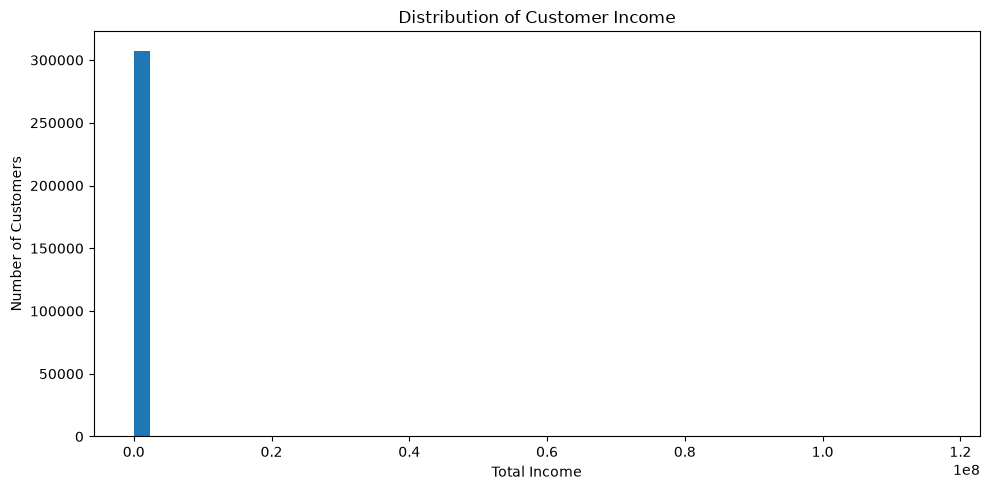

In [36]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    df["AMT_INCOME_TOTAL"].dropna(),
    bins=50,
)

ax.set_title("Distribution of Customer Income")
ax.set_xlabel("Total Income")
ax.set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

##### <b>Observation</b>

The income distribution is expected to be strongly right-skewed.

Most customers fall within lower or moderate income ranges, while a small number of customers have extremely high incomes.

These extreme values stretch the horizontal scale and make the main distribution difficult to inspect.

#### <b>Step 6: Visualize the Main Income Distribution</b>

Because extreme values can compress the main part of the histogram, we inspect income values below the 99th percentile.

This is only for visualization.

No records are removed from the dataset.

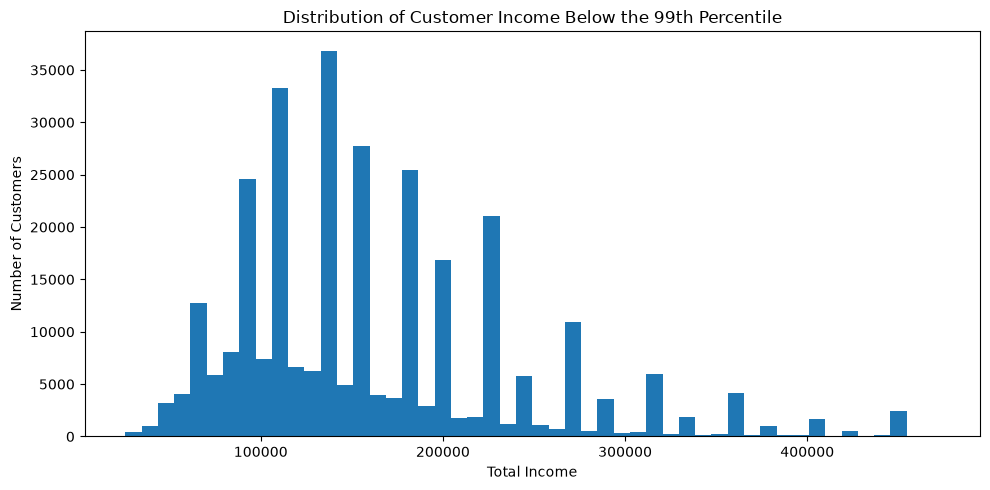

In [37]:
income_99th_percentile = df[
    "AMT_INCOME_TOTAL"
].quantile(0.99)

income_for_visualization = df.loc[
    df["AMT_INCOME_TOTAL"]
    <= income_99th_percentile,
    "AMT_INCOME_TOTAL",
]

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    income_for_visualization.dropna(),
    bins=50,
)

ax.set_title(
    "Distribution of Customer Income Below the 99th Percentile"
)
ax.set_xlabel("Total Income")
ax.set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

##### <b>Business Insight</b>

Most applicants are concentrated within a limited income range.

A small number of very high-income applicants create a long right tail.

For modeling, we may later consider:

- Log transformation
- Robust scaling
- Outlier capping
- Income-related ratio features

However, high-income values should not be removed automatically because they may represent genuine customers.

#### <b>Step 7: Analyze Loan Credit Amount</b>

`AMT_CREDIT` represents the total loan amount requested or granted.

Credit amount is an important business feature because larger loans may create greater financial exposure.

However, default risk depends not only on the loan amount, but also on the customer's income, repayment capacity, and loan terms.

In [38]:
df["AMT_CREDIT"].describe()

count    3.075110e+05
mean     5.990260e+05
std      4.024908e+05
min      4.500000e+04
25%      2.700000e+05
50%      5.135310e+05
75%      8.086500e+05
max      4.050000e+06
Name: AMT_CREDIT, dtype: float64

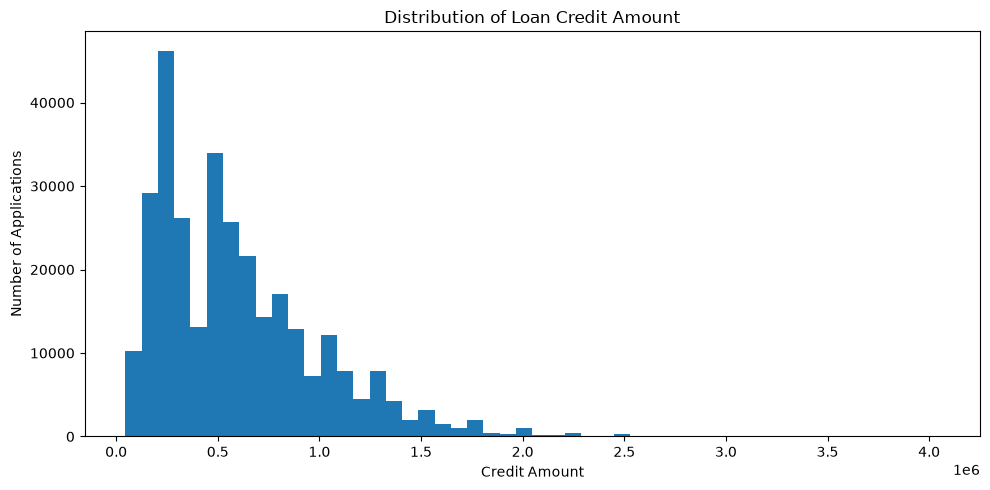

In [39]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    df["AMT_CREDIT"].dropna(),
    bins=50,
)

ax.set_title("Distribution of Loan Credit Amount")
ax.set_xlabel("Credit Amount")
ax.set_ylabel("Number of Applications")

plt.tight_layout()
plt.show()

##### <b>Observation</b>

The credit-amount distribution may show several peaks rather than a perfectly smooth pattern.

This can happen because loan amounts are often offered in standard packages or rounded values.

The distribution may also be right-skewed, with fewer applications involving very large loan amounts.

#### <b>Step 8: Analyze Loan Annuity</b>

`AMT_ANNUITY` represents the periodic repayment amount.

A higher annuity may place greater pressure on a customer's monthly budget.

However, its effect should be analyzed relative to income rather than independently.

In [40]:
df["AMT_ANNUITY"].describe()

count    307499.000000
mean      27108.573909
std       14493.737315
min        1615.500000
25%       16524.000000
50%       24903.000000
75%       34596.000000
max      258025.500000
Name: AMT_ANNUITY, dtype: float64

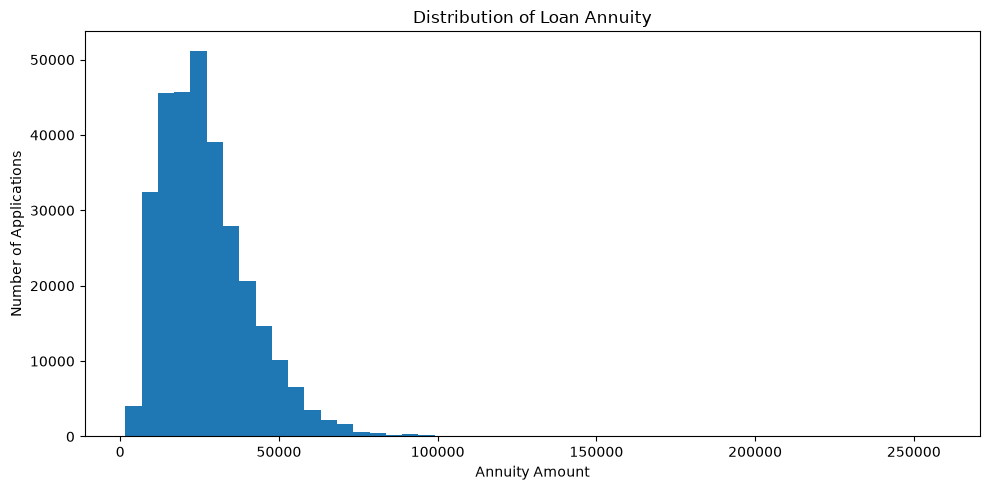

In [41]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    df["AMT_ANNUITY"].dropna(),
    bins=50,
)

ax.set_title("Distribution of Loan Annuity")
ax.set_xlabel("Annuity Amount")
ax.set_ylabel("Number of Applications")

plt.tight_layout()
plt.show()

##### <b>Business Insight</b>

The annuity amount alone may not clearly indicate default risk.

A more useful feature may be the ratio between annuity and income:

`ANNUITY_INCOME_RATIO = AMT_ANNUITY / AMT_INCOME_TOTAL`

A high ratio may indicate that a large portion of the customer's income is required for loan repayment.

#### <b>Step 9: Analyze Goods Price</b>

`AMT_GOODS_PRICE` represents the price of the goods for which the loan was provided.

This feature is usually related to the credit amount.

A large difference between goods price and credit amount may reveal financing structure, down-payment behavior, or additional costs.

In [42]:
df["AMT_GOODS_PRICE"].describe()

count    3.072330e+05
mean     5.383962e+05
std      3.694465e+05
min      4.050000e+04
25%      2.385000e+05
50%      4.500000e+05
75%      6.795000e+05
max      4.050000e+06
Name: AMT_GOODS_PRICE, dtype: float64

In [43]:
credit_goods_summary = df[
    [
        "AMT_CREDIT",
        "AMT_GOODS_PRICE",
    ]
].describe().T

credit_goods_summary

,count,mean,std,min,25%,50%,75%,max
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
AMT_GOODS_PRICE,307233.0,538396.207429,369446.460540,40500.0,238500.0,450000.0,679500.0,4050000.0


##### <b>Feature Engineering Idea</b>

We may later create:

`CREDIT_GOODS_RATIO = AMT_CREDIT / AMT_GOODS_PRICE`

This ratio may help identify whether the loan amount is high relative to the underlying goods price.

#### <b>Step 10: Analyze Customer Age</b>

`DAYS_BIRTH` stores customer age as a negative number of days relative to the loan application date.

For easier interpretation, we temporarily convert it to years:

`AGE_YEARS = -DAYS_BIRTH / 365.25`

This conversion is used only for analysis at this stage.

In [44]:
age_years = (
    -df["DAYS_BIRTH"] / 365.25
)

age_years.describe()

count    307511.000000
mean         43.906900
std          11.947950
min          20.503765
25%          33.984942
50%          43.121150
75%          53.886379
max          69.073238
Name: DAYS_BIRTH, dtype: float64

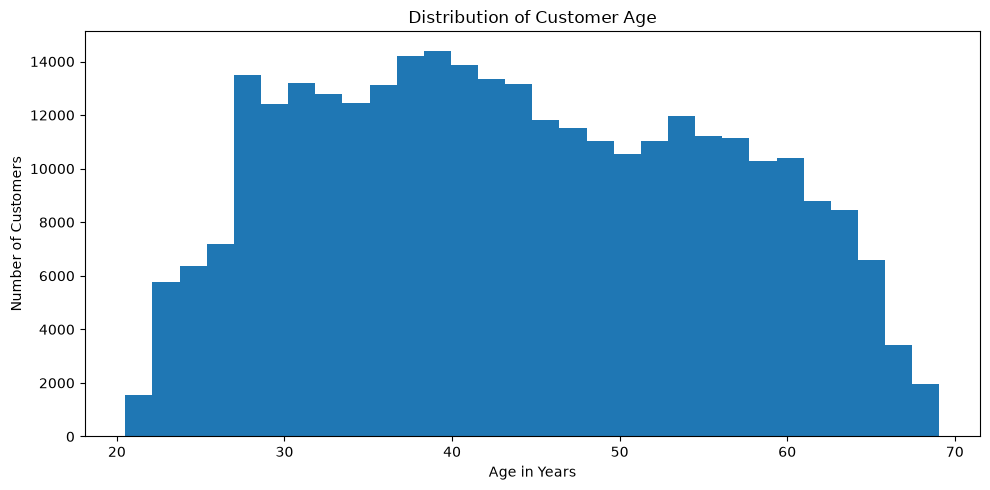

In [45]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    age_years.dropna(),
    bins=30,
)

ax.set_title("Distribution of Customer Age")
ax.set_xlabel("Age in Years")
ax.set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

##### <b>Observation</b>

The applicant population covers a broad range of ages.

Age may be associated with:

- Employment stability
- Credit history length
- Income stability
- Family responsibilities
- Retirement status

Age should be interpreted carefully because it may also introduce fairness and regulatory concerns in lending decisions.

#### <b>Step 11: Compare Customer Age by Default Status</b>

We compare the average and median age of:

- Non-default customers
- Default customers

This helps identify whether age patterns differ between the two groups.

In [46]:
age_target_analysis = pd.DataFrame(
    {
        "TARGET": df["TARGET"],
        "AGE_YEARS": age_years,
    }
)

age_by_target = (
    age_target_analysis
    .groupby("TARGET")["AGE_YEARS"]
    .agg(
        [
            "mean",
            "median",
            "min",
            "max",
        ]
    )
    .round(2)
)

print(age_by_target)

         mean  median    min    max
TARGET                             
0       44.18   43.47  20.50  69.07
1       40.75   39.10  21.02  68.91


##### <b>Interpretation</b>

If the average age of defaulters differs from that of non-defaulters, age may contain predictive information.

However, a difference in averages does not prove causation.

Further analysis and model validation are required before drawing conclusions.

#### <b>Step 12: Analyze Employment Duration</b>

`DAYS_EMPLOYED` represents the number of days the customer has been employed.

The values are recorded as negative numbers.

A longer employment history may indicate greater income stability.

However, this feature contains a known unusual value that requires investigation.

In [47]:
df["DAYS_EMPLOYED"].describe()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

#### <b>Step 13: Investigate Unusual Employment Values</b>

Some records in `DAYS_EMPLOYED` contain the value `365243`.

This value does not represent a realistic employment duration.

It is commonly treated as a special placeholder indicating unavailable or non-applicable employment information.

In [48]:
special_employment_value = 365243

special_employment_count = int(
    (
        df["DAYS_EMPLOYED"]
        == special_employment_value
    ).sum()
)

special_employment_percentage = (
    special_employment_count / len(df)
) * 100

print(
    "Special employment value count:",
    f"{special_employment_count:,}",
)

print(
    "Special employment value percentage:",
    f"{special_employment_percentage:.2f}%",
)

Special employment value count: 55,374
Special employment value percentage: 18.01%


##### <b>Observation</b>

The value `365243` is not a realistic employment duration.

It should not be treated as a normal numerical value because it would distort:

- Mean
- Standard deviation
- Distribution
- Scaling
- Model relationships

During preprocessing, this value may be replaced with a missing value and handled separately.

#### <b>Step 14: Analyze Employment Duration After Excluding the Special Value</b>

For exploratory visualization, we exclude the special placeholder value and convert valid employment duration into years.

This does not permanently modify the dataset.

In [49]:
valid_employment_days = df.loc[
    df["DAYS_EMPLOYED"] != special_employment_value,
    "DAYS_EMPLOYED",
]

employment_years = (
    -valid_employment_days / 365.25
)

employment_years.describe()

count    252137.000000
mean          6.527500
std           6.402081
min           0.000000
25%           2.099932
50%           4.511978
75%           8.692676
max          49.040383
Name: DAYS_EMPLOYED, dtype: float64

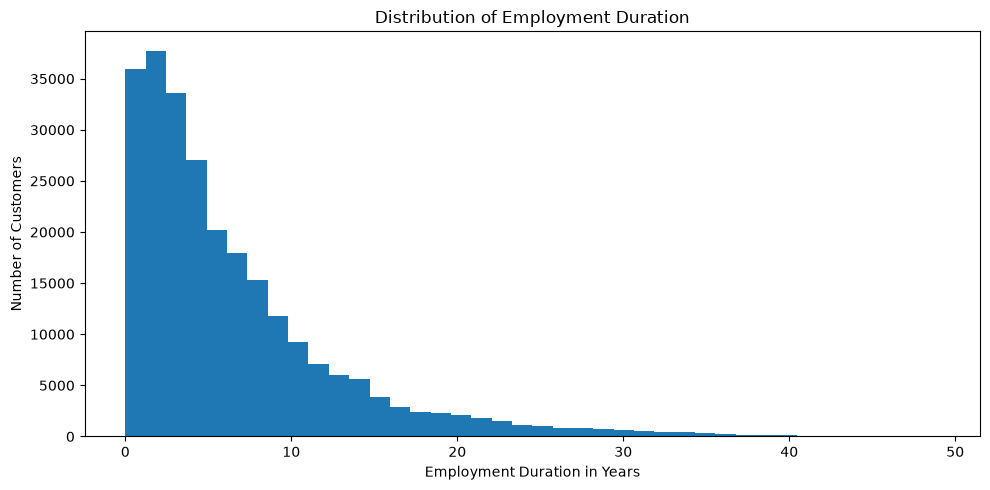

In [50]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    employment_years.dropna(),
    bins=40,
)

ax.set_title("Distribution of Employment Duration")
ax.set_xlabel("Employment Duration in Years")
ax.set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

##### <b>Business Insight</b>

Employment duration may indicate job stability and repayment capacity.

Customers with very short employment histories may have less stable income.

However, employment duration should be interpreted together with:

- Age
- Occupation
- Income
- Employment type
- Organization type

#### <b>Step 15: Analyze Number of Children</b>

`CNT_CHILDREN` represents the number of children in the customer's family.

This variable may influence household expenses and repayment capacity.

Because this is a discrete count variable, its distribution should be analyzed differently from continuous financial features.

In [51]:
children_counts = (
    df["CNT_CHILDREN"]
    .value_counts()
    .sort_index()
)

children_counts.head(15)

CNT_CHILDREN
0     215371
1      61119
2      26749
3       3717
4        429
5         84
6         21
7          7
8          2
9          2
10         2
11         1
12         2
14         3
19         2
Name: count, dtype: int64

[2026-07-23 14:16:17,639] INFO - matplotlib.category - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[2026-07-23 14:16:17,666] INFO - matplotlib.category - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


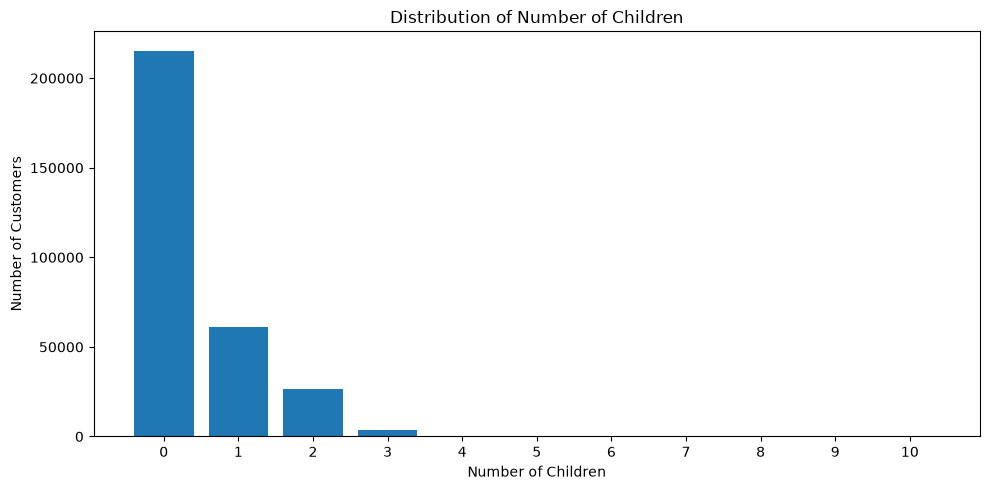

In [52]:
children_plot_data = children_counts[
    children_counts.index <= 10
]

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    children_plot_data.index.astype(str),
    children_plot_data.values,
)

ax.set_title("Distribution of Number of Children")
ax.set_xlabel("Number of Children")
ax.set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

##### <b>Observation</b>

Most customers are expected to have zero or a small number of children.

Very large values may be rare and should be reviewed as possible outliers or genuine large-family records.

The number of children should not be treated exactly like a continuous financial feature.

#### <b>Step 16: Analyze Family Size</b>

`CNT_FAM_MEMBERS` represents the number of people in the customer's family.

Family size may affect household expenses and disposable income.

Missing values and unusual family sizes should be reviewed before modeling.

In [53]:
df["CNT_FAM_MEMBERS"].describe()

count    307509.000000
mean          2.152665
std           0.910682
min           1.000000
25%           2.000000
50%           2.000000
75%           3.000000
max          20.000000
Name: CNT_FAM_MEMBERS, dtype: float64

In [54]:
family_member_counts = (
    df["CNT_FAM_MEMBERS"]
    .value_counts()
    .sort_index()
)

family_member_counts.head(15)

CNT_FAM_MEMBERS
1.0      67847
2.0     158357
3.0      52601
4.0      24697
5.0       3478
6.0        408
7.0         81
8.0         20
9.0          6
10.0         3
11.0         1
12.0         2
13.0         1
14.0         2
15.0         1
Name: count, dtype: int64

#### <b>Step 17: Analyze External Credit Scores</b>

The features:

- `EXT_SOURCE_1`
- `EXT_SOURCE_2`
- `EXT_SOURCE_3`

represent external risk-score information.

These features may be strong predictors of default risk.

Higher or lower score interpretations should be confirmed from the data and official feature descriptions rather than assumed without analysis.

In [55]:
external_source_columns = [
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
]

df[external_source_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
EXT_SOURCE_1,134133.0,0.502130,0.211062,1.456813e-02,0.334007,0.505998,0.675053,0.962693
EXT_SOURCE_2,306851.0,0.514393,0.191060,8.173617e-08,0.392457,0.565961,0.663617,0.855000
EXT_SOURCE_3,246546.0,0.510853,0.194844,5.272652e-04,0.370650,0.535276,0.669057,0.896010


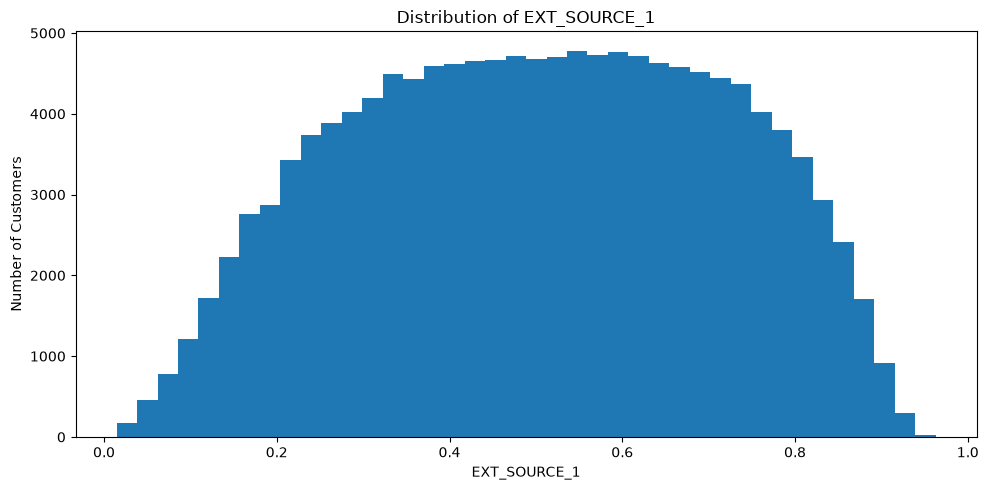

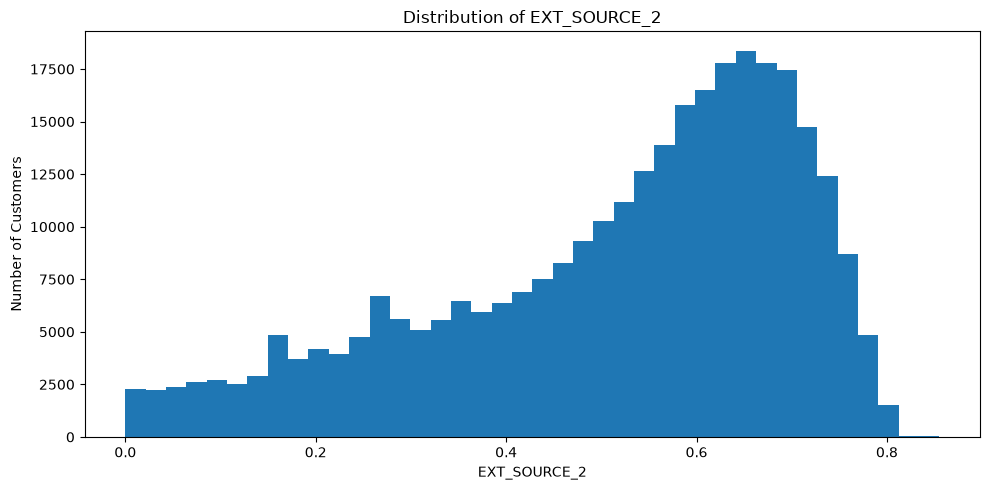

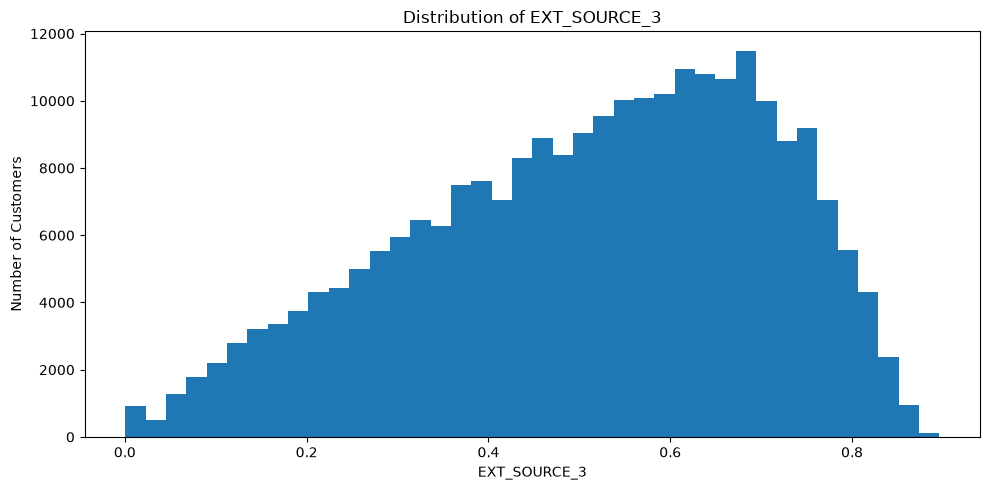

In [56]:
for column in external_source_columns:
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.hist(
        df[column].dropna(),
        bins=40,
    )

    ax.set_title(f"Distribution of {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Number of Customers")

    plt.tight_layout()
    plt.show()

##### <b>Observation</b>

The external-source features have different missing-value rates and distributions.

They should not automatically be combined or imputed using the same rule.

Their relationship with the target variable should be examined before deciding how to use them.

#### <b>Step 18: Compare Numerical Features Across Target Classes</b>

We compare the mean and median values of important numerical features for:

- Class `0`: No default
- Class `1`: Default

This helps identify features whose distributions may differ between defaulters and non-defaulters.

In [ ]:
target_comparison_features = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
]

available_target_comparison_features = [
    column
    for column in target_comparison_features
    if column in df.columns
]

mean_by_target = (
    df.groupby("TARGET")[
        available_target_comparison_features
    ]
    .mean()
    .T
    .round(2)
)

mean_by_target.columns = [
    "No_Default_Mean",
    "Default_Mean",
]

print(mean_by_target)

,No_Default_Mean,Default_Mean
AMT_INCOME_TOTAL,169077.72,165611.76
AMT_CREDIT,602648.28,557778.53
AMT_ANNUITY,27163.62,26481.74
AMT_GOODS_PRICE,542736.80,488972.41
CNT_CHILDREN,0.41,0.46
CNT_FAM_MEMBERS,2.15,2.18
EXT_SOURCE_1,0.51,0.39
EXT_SOURCE_2,0.52,0.41
EXT_SOURCE_3,0.52,0.39


In [58]:
median_by_target = (
    df.groupby("TARGET")[
        available_target_comparison_features
    ]
    .median()
    .T
    .round(2)
)

median_by_target.columns = [
    "No_Default_Median",
    "Default_Median",
]

print(median_by_target)

                  No_Default_Median  Default_Median
AMT_INCOME_TOTAL          148500.00       135000.00
AMT_CREDIT                517788.00       497520.00
AMT_ANNUITY                24876.00        25263.00
AMT_GOODS_PRICE           450000.00       450000.00
CNT_CHILDREN                   0.00            0.00
CNT_FAM_MEMBERS                2.00            2.00
EXT_SOURCE_1                   0.52            0.36
EXT_SOURCE_2                   0.57            0.44
EXT_SOURCE_3                   0.55            0.38


##### <b>Interpretation</b>

Differences between class-level means and medians may suggest that certain features are associated with default risk.

However:

- Averages can be affected by outliers.
- Association does not imply causation.
- A difference does not guarantee strong predictive power.
- Statistical and model-based validation will still be required.

#### <b>Step 19: Compare Selected Numerical Features Using Box Plots</b>

Box plots help compare the distribution of a numerical feature across target classes.

They display:

- Median
- Lower quartile
- Upper quartile
- Interquartile range
- Potential outliers

Because some financial variables contain extreme values, we use percentile-based limits for visualization only.

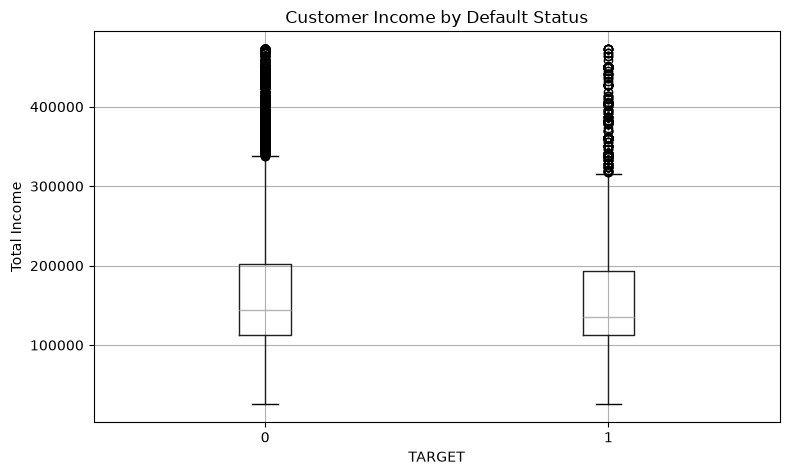

In [59]:
income_upper_limit = df[
    "AMT_INCOME_TOTAL"
].quantile(0.99)

income_box_data = df.loc[
    df["AMT_INCOME_TOTAL"]
    <= income_upper_limit,
    [
        "TARGET",
        "AMT_INCOME_TOTAL",
    ],
]

fig, ax = plt.subplots(figsize=(8, 5))

income_box_data.boxplot(
    column="AMT_INCOME_TOTAL",
    by="TARGET",
    ax=ax,
)

ax.set_title("Customer Income by Default Status")
ax.set_xlabel("TARGET")
ax.set_ylabel("Total Income")

plt.suptitle("")
plt.tight_layout()
plt.show()

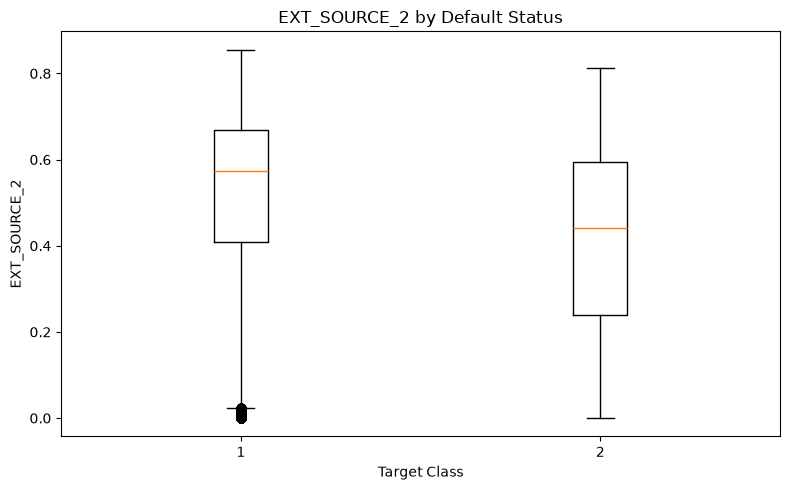

In [63]:
external_score_data = [
    df.loc[
        df["TARGET"] == target_value,
        "EXT_SOURCE_2",
    ].dropna()
    for target_value in [0, 1]
]

fig, ax = plt.subplots(figsize=(8, 5))

ax.boxplot(
    external_score_data,
    label=[
        "No Default",
        "Default",
    ],
)

ax.set_title("EXT_SOURCE_2 by Default Status")
ax.set_xlabel("Target Class")
ax.set_ylabel("EXT_SOURCE_2")

plt.tight_layout()
plt.show()

##### <b>Observation</b>

Box plots may reveal differences in median values and distribution ranges between defaulters and non-defaulters.

Features with visible separation between the two classes may contain useful predictive information.

However, overlapping distributions are expected because no single feature is likely to perfectly separate default and non-default customers.

#### <b>Step 20: Identify Highly Skewed Numerical Features</b>

Highly skewed features may affect:

- Linear models
- Distance-based models
- Scaling
- Statistical interpretation

We identify numerical features whose absolute skewness is greater than `1`.

In [61]:
model_numerical_columns = [
    column
    for column in numerical_columns
    if column not in [
        "TARGET",
        "SK_ID_CURR",
    ]
]

numerical_skewness = (
    df[model_numerical_columns]
    .skew()
    .sort_values(
        key=lambda values: values.abs(),
        ascending=False,
    )
)

highly_skewed_features = numerical_skewness[
    numerical_skewness.abs() > 1
]

print(
    "Number of highly skewed numerical features:",
    len(highly_skewed_features),
)

highly_skewed_features.head(20)

Number of highly skewed numerical features: 86


FLAG_MOBIL                  -554.536744
FLAG_DOCUMENT_12             392.114779
AMT_INCOME_TOTAL             391.559654
FLAG_DOCUMENT_10             209.589054
FLAG_DOCUMENT_2              153.791817
AMT_REQ_CREDIT_BUREAU_QRT    134.365776
FLAG_DOCUMENT_4              110.894364
FLAG_DOCUMENT_7               72.174108
FLAG_DOCUMENT_17              61.214140
FLAG_DOCUMENT_21              54.612939
FLAG_DOCUMENT_20              44.364897
FLAG_DOCUMENT_19              40.956134
FLAG_DOCUMENT_15              28.699333
AMT_REQ_CREDIT_BUREAU_DAY     27.043505
FLAG_CONT_MOBILE             -23.081172
FLAG_DOCUMENT_14              18.372533
FLAG_DOCUMENT_13              16.753746
NONLIVINGAPARTMENTS_MODE      16.251819
FLAG_DOCUMENT_9               15.927755
FLAG_DOCUMENT_11              15.894229
dtype: float64

##### <b>Interpretation</b>

Highly skewed features may later require transformations such as:

- `log1p`
- Square-root transformation
- Quantile transformation
- Robust scaling
- Capping extreme values

The final decision should depend on the selected algorithm.

Tree-based models are generally less sensitive to skewness than linear or distance-based models.

#### <b>Step 21: Check for Infinite Numerical Values</b>

Infinite values can cause preprocessing and model-training failures.

They may appear after incorrect mathematical calculations or divisions.

We check whether the original numerical features contain positive or negative infinity.

In [62]:
infinite_value_count = int(
    np.isinf(
        df[numerical_columns]
        .select_dtypes(include="number")
    )
    .sum()
    .sum()
)

print(
    "Total infinite values:",
    infinite_value_count,
)

Total infinite values: 0


#### <b>Step 22: Preliminary Numerical Preprocessing Decisions</b>

Based on the numerical analysis, the following strategies may be evaluated later:

##### Missing Values

- Median imputation for skewed numerical features
- Missing indicators where missingness may be informative

##### Extreme Values

- Validate using business rules
- Use percentile capping where justified
- Avoid automatic deletion

##### Skewed Features

- Log transformation
- Robust scaling
- Tree-based models

##### Date-Based Features

- Convert negative day values into interpretable years
- Replace special placeholder values such as `365243`

##### Ratio Features

Potential engineered features include:

- Credit-to-income ratio
- Annuity-to-income ratio
- Credit-to-goods-price ratio
- Employment-to-age ratio
- Income per family member

##### <b>Important Reminder: Outliers Are Not Always Errors</b>

An extreme numerical value may represent:

- A wealthy customer
- A large loan application
- A large family
- A data-entry problem
- A special placeholder value

Therefore, outliers should not be removed automatically.

Each unusual value should be investigated using:

- Business meaning
- Feature documentation
- Distribution analysis
- Model performance

#### <b>Business Insights</b>

1. Income, credit, annuity, and goods-price features are generally right-skewed.
2. Financial features contain extreme values that may represent genuine customers.
3. Credit and annuity should be analyzed relative to income rather than independently.
4. Age and employment duration are stored as day-based values and require conversion for interpretation.
5. `DAYS_EMPLOYED` contains a special value that should not be treated as a normal duration.
6. Family-size features are discrete counts rather than continuous measurements.
7. External credit-source features may have strong relationships with default risk.
8. No single numerical feature is expected to perfectly distinguish defaulters from non-defaulters.
9. Ratio-based features may provide better business information than raw values alone.

#### <b>Session 4 Summary</b>

In this session, we:

- Identified numerical features
- Generated statistical summaries
- Measured skewness
- Analyzed income, credit, annuity, and goods price
- Converted age into years for interpretation
- Investigated employment duration
- Detected the special `DAYS_EMPLOYED` value
- Analyzed children and family size
- Studied external credit scores
- Compared numerical features across target classes
- Used box plots to compare distributions
- Identified highly skewed features
- Checked for infinite values
- Defined preliminary preprocessing and feature-engineering strategies

No numerical feature was permanently modified or removed during this session.

The next session will focus on categorical-feature analysis.